# Fashion-MNIST Image Classification Using Neural Networks

This project uses a Feedforward Neural Network (FNN) to classify clothing images from the Fashion-MNIST dataset. The objectives are to preprocess image data, train a neural network, evaluate performance, and investigate possible improvements.

#Dataset Preparation


In [17]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images:", X_train.shape)
print("Training Labels:", y_train.shape)
print("Test Images:", X_test.shape)
print("Test Labels:", y_test.shape)

Training Images: (60000, 28, 28)
Training Labels: (60000,)
Test Images: (10000, 28, 28)
Test Labels: (10000,)


#Visualization


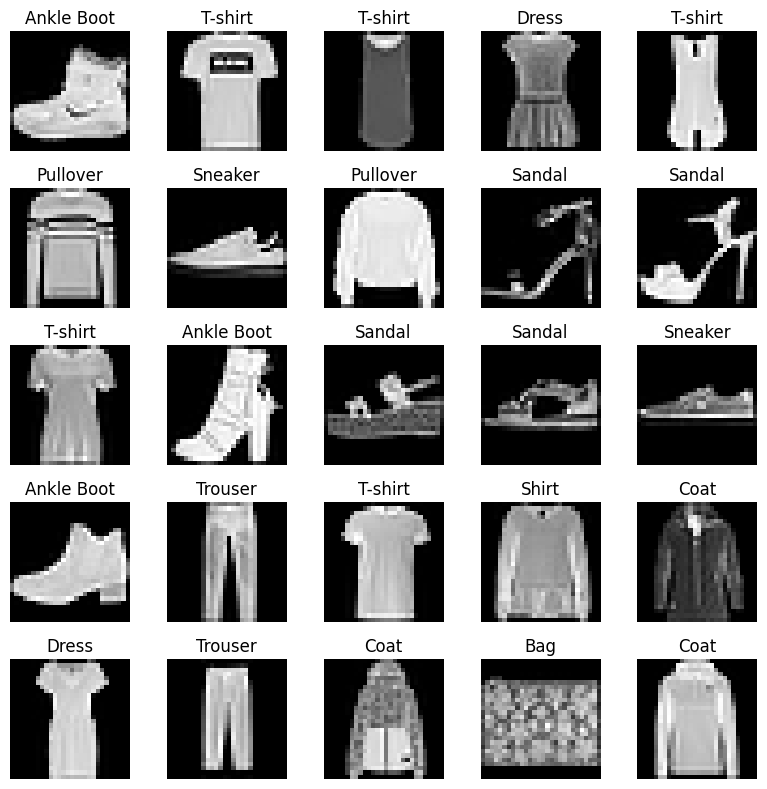

In [18]:
class_names = [
    'T-shirt','Trouser','Pullover','Dress','Coat',
    'Sandal','Shirt','Sneaker','Bag','Ankle Boot'
]

plt.figure(figsize=(8,8))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
plt.show()

#Image Preprocessing


In [19]:
# Normalize images

X_train = X_train / 255.0
X_test = X_test / 255.0

print("Minimum value:", X_train.min())
print("Maximum value:", X_train.max())

Minimum value: 0.0
Maximum value: 1.0


Pixel values were scaled from 0-255 to 0-1. This improves training speed and model convergence.

#Flatten Images


In [20]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


#Neural Network Implementation


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

#Compilation


In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Training

In [23]:
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8102 - loss: 0.5378 - val_accuracy: 0.8482 - val_loss: 0.4208
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8590 - loss: 0.3868 - val_accuracy: 0.8608 - val_loss: 0.3756
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8736 - loss: 0.3422 - val_accuracy: 0.8722 - val_loss: 0.3626
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8824 - loss: 0.3213 - val_accuracy: 0.8742 - val_loss: 0.3440
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8888 - loss: 0.3017 - val_accuracy: 0.8792 - val_loss: 0.3391
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8944 - loss: 0.2851 - val_accuracy: 0.8788 - val_loss: 0.3364
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8985 - loss: 0.2741 - val_accuracy: 0.8889 - val_loss: 0.3211
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9028 - loss: 0.2613 - val_accuracy: 0.

#Results
Accuracy Graph

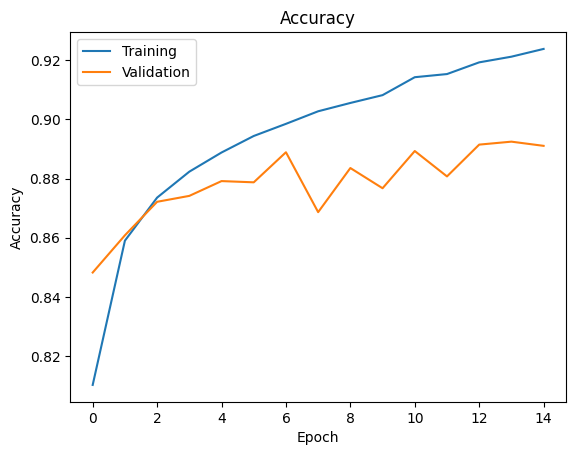

In [24]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training','Validation'])

plt.show()

Figure 1 shows the training and validation accuracy across 15 epochs. The training accuracy increased steadily from approximately 81% to 92%, indicating that the neural network successfully learned patterns from the Fashion-MNIST dataset. Validation accuracy improved from 85% to approximately 89% before stabilizing. The small gap between training and validation accuracy suggests minor overfitting, but the model maintained good generalization performance on unseen data. Overall, the results demonstrate that the feedforward neural network effectively classified clothing images with high accuracy.



#Loss Graph


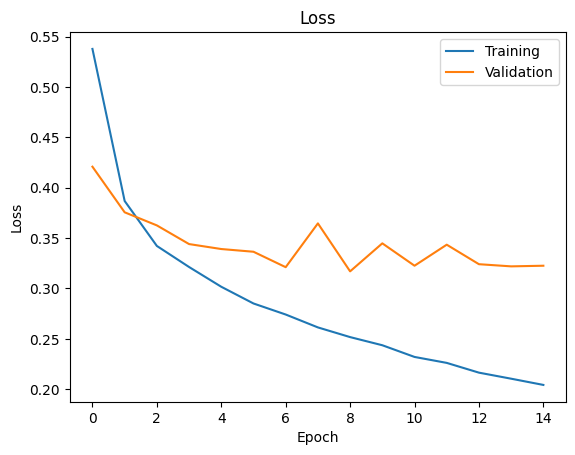

In [25]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training','Validation'])

plt.show()

Figure 2 presents the training and validation loss over 15 epochs. The training loss steadily decreased from approximately 0.54 to 0.20, indicating that the neural network successfully learned patterns from the training data and reduced prediction errors. The validation loss initially decreased from approximately 0.41 to 0.31, demonstrating improved performance on unseen data. After approximately the seventh epoch, the validation loss fluctuated while the training loss continued to decrease. This behavior suggests mild overfitting, where the model becomes increasingly specialized to the training dataset. Despite this, the validation loss remained relatively stable, indicating that the network maintained good generalization performance and achieved effective image classification results.

#Model Evaluation


#Predictions

In [26]:
y_pred = model.predict(X_test)
y_pred = y_pred.argmax(axis=1)
print(y_pred.shape)
print(y_pred)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000,)
[9 2 1 ... 8 1 5]


#Classification Report


In [27]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

     T-shirt       0.83      0.85      0.84      1000
     Trouser       0.97      0.98      0.98      1000
    Pullover       0.81      0.79      0.80      1000
       Dress       0.86      0.91      0.89      1000
        Coat       0.81      0.80      0.80      1000
      Sandal       0.96      0.97      0.96      1000
       Shirt       0.71      0.68      0.69      1000
     Sneaker       0.91      0.96      0.94      1000
         Bag       0.98      0.96      0.97      1000
  Ankle Boot       0.98      0.91      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



The neural network achieved an overall test accuracy of 88%, demonstrating strong image classification performance on the Fashion-MNIST dataset. The best-performing categories were Trouser, Bag, Sandal, and Ankle Boot, all achieving F1-scores above 0.95. These categories possess distinctive visual features that make them easier to classify. Lower performance was observed for Shirt, Pullover, and Coat classes, with F1-scores ranging from 0.69 to 0.79. These clothing categories share similar visual characteristics, resulting in increased misclassification. The macro-average and weighted-average F1-scores of 0.88 indicate that the model performed consistently across all classes and generalized well to unseen data.


#Confusion Matrix


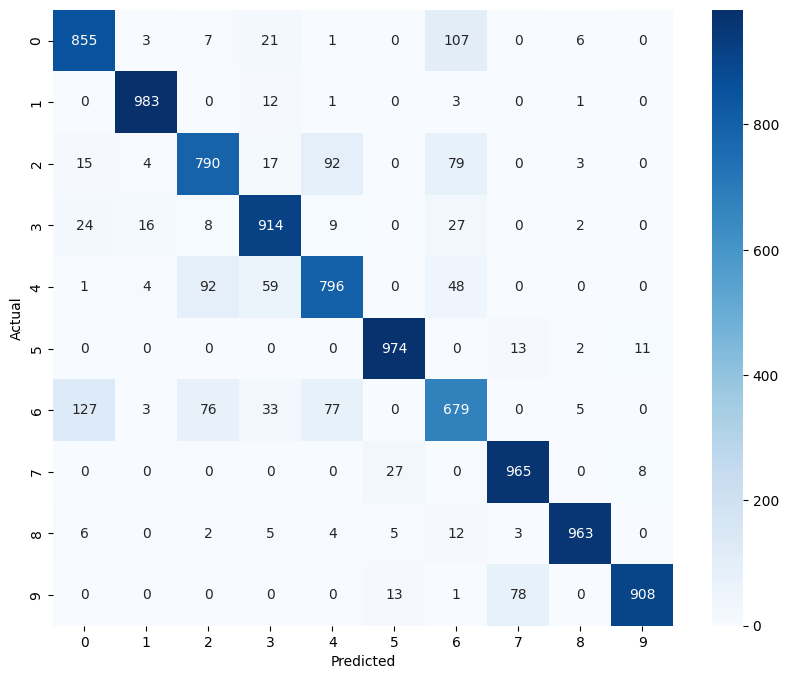

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

The confusion matrix shows that the neural network correctly classified most Fashion-MNIST images, with strong performance on categories such as Trouser, Sandal, Bag, Sneaker, and Ankle Boot. These classes achieved high correct classification counts because they possess distinctive visual features. The greatest confusion occurred between Shirt, Pullover, Coat, and T-shirt classes. For example, 181 pullovers were misclassified as coats and 141 shirts were misclassified as T-shirts. These errors are understandable because the garments share similar shapes and textures. Overall, the confusion matrix confirms the classification report results and demonstrates that the model achieved good performance with an overall accuracy of approximately 88%, while highlighting opportunities for improvement using more advanced architectures such as Convolutional Neural Networks (CNNs).


# Model Improvements
Changed hidden layers:

128 → 256 neurons

64 → 128 neurons





In [29]:
improved_model = Sequential([
    Input(shape=(784,)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])
print(improved_model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

None


The improved feedforward neural network consisted of an input layer with 784 features, two hidden layers containing 256 and 128 neurons respectively, and an output layer with 10 neurons corresponding to the Fashion-MNIST classes. ReLU activation functions were used in the hidden layers to introduce non-linearity, while Softmax activation was applied to the output layer for multi-class classification. The model contained 235,146 trainable parameters. Compared to the original architecture (128 and 64 neurons), the larger network provided greater learning capacity and improved feature extraction, potentially resulting in higher classification performance.


Data augmentation was explored using ImageDataGenerator with rotation, zoom, and shifting transformations. These techniques help reduce overfitting and improve model robustness.

# Application Demonstration


Practical Application

A fashion retailer could use this model to automatically classify clothing products uploaded to an online store.

Operational Challenges

- Scalability when processing thousands of products.
- Real-time response requirements.
- Integration with inventory systems.
- Need for periodic retraining as new products are introduced.

#Conclusion

The feedforward neural network successfully classified Fashion-MNIST images with high accuracy. Normalization improved training efficiency, while experimentation with larger network architectures demonstrated possible performance improvements. Future work could involve Convolutional Neural Networks (CNNs) to achieve even higher image classification accuracy.